In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\Viplavi\Downloads\creditcard.csv")

# Check for missing values
df.isnull().sum()

# Drop rows with missing target variables (fraud or not)
df.dropna(subset=['target'], inplace=True)

# Feature selection (assuming 'target' column is the label)
X = df.drop(columns=['target'])
y = df['target']

# Data normalization/standardization (StandardScaler is often used for machine learning models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


ModuleNotFoundError: No module named 'imblearn'

In [2]:
!pip install imbalanced-learn


  Using cached imbalanced_learn-0.13.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached sklearn_compat-0.1.3-py3-none-any.whl.metadata (18 kB)
Using cached imbalanced_learn-0.13.0-py3-none-any.whl (238 kB)
Using cached sklearn_compat-0.1.3-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from imblearn.over_sampling import SMOTE

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv(r"C:\Users\Viplavi\Downloads\creditcard.csv")

# Check for missing values
df.isnull().sum()

# Drop rows with missing target variables (fraud or not)
df.dropna(subset=['target'], inplace=True)

# Feature selection (assuming 'target' column is the label)
X = df.drop(columns=['target'])
y = df['target']

# Data normalization/standardization (StandardScaler is often used for machine learning models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


KeyError: ['target']

In [5]:
print(df.columns)


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [6]:
df.dropna(subset=['Class'], inplace=True)

# Split features and target
X = df.drop(columns=['Class'])
y = df['Class']

# Standardize 'Amount' and 'Time' features (optional but common)
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
# Data normalization/standardization (StandardScaler is often used for machine learning models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split the dataset into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)


In [10]:
from xgboost import XGBClassifier

# Initialize the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=1000,   # Number of trees
    learning_rate=0.01,  # Learning rate (controls step size)
    max_depth=6,         # Maximum depth of a tree
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the validation set
y_pred = xgb_model.predict(X_valid)
y_prob = xgb_model.predict_proba(X_valid)[:, 1]  # Probabilities for ROC and AUC


In [11]:
print ("classification_report:")
print(classification_report(y_valid, y_pred))

from sklearn.metrics import average_precision_score
auprc = average_precision_score(y_valid, y_prob)
print(f"AUPRC sCORE: {auprc: .4f}")


classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

AUPRC sCORE:  0.9999


In [12]:
from sklearn.metrics import roc_curve, auc

In [14]:
fpr, tpr, _ = roc_curve(y_valid, y_prob)
roc_auc = auc(fpr, tpr)

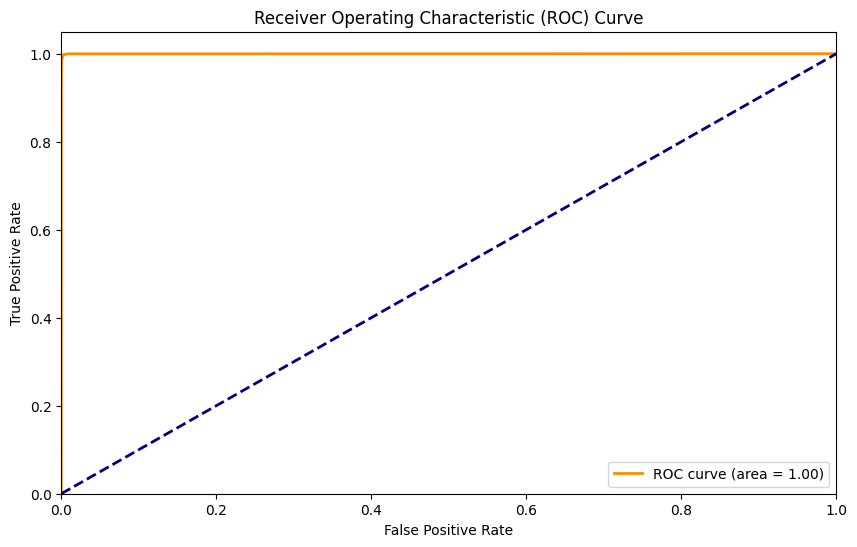

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

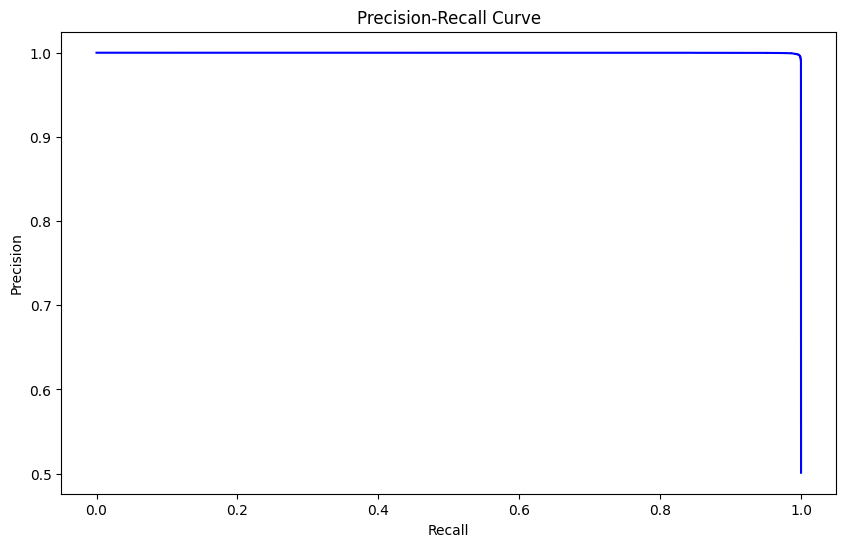

In [16]:
precision, recall, _ = precision_recall_curve(y_valid, y_prob)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='b', label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

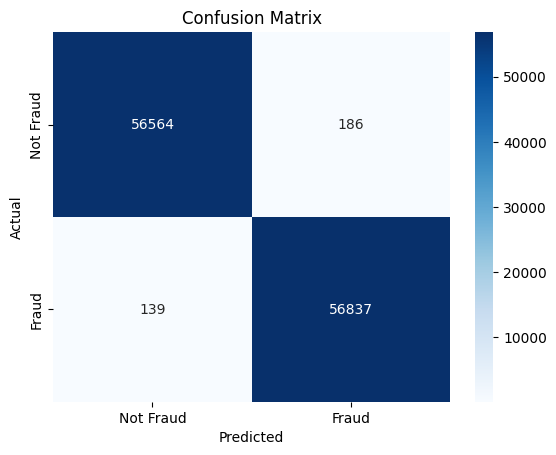

In [17]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_valid, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'n_estimators': [500, 1000],
}

grid_search = GridSearchCV(XGBClassifier(), param_grid, cv=3, scoring='roc_auc', verbose=1)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)


Fitting 3 folds for each of 18 candidates, totalling 54 fits


KeyboardInterrupt: 